# Feature Engineering

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.decomposition import PCA
import ast
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import KFold
import pyarrow
import timm
import torch
import json

In [2]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
df = pd.read_parquet("../data/processed/anime_data_1.parquet")
df.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   year          5338 non-null   float64
 6   season        5338 non-null   str    
 7   producers     5338 non-null   object 
 8   genres        5338 non-null   object 
 9   studios       5338 non-null   object 
 10  demographics  5338 non-null   object 
 11  themes        5338 non-null   object 
 12  rating        5338 non-null   str    
 13  sequel        5338 non-null   bool   
 14  favorites     5338 non-null   int64  
 15  score         5338 non-null   float64
 16  wc            5338 non-null   int64  
 17  dropped       5338 non-null   int64  
 18  forum         5338 non-null   int64  
dtypes

## Cohort

Combine Season + Year into one "Cohort" variable

In [4]:
df['cohort'] = df['season'] +  " " + df['year'].astype(int).astype(str)
df['cohort'].describe()

count          5338
unique          246
top       fall 2016
freq             70
Name: cohort, dtype: object

In [5]:
df2 = df.drop(columns=['year', 'season'])
df2.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   producers     5338 non-null   object 
 6   genres        5338 non-null   object 
 7   studios       5338 non-null   object 
 8   demographics  5338 non-null   object 
 9   themes        5338 non-null   object 
 10  rating        5338 non-null   str    
 11  sequel        5338 non-null   bool   
 12  favorites     5338 non-null   int64  
 13  score         5338 non-null   float64
 14  wc            5338 non-null   int64  
 15  dropped       5338 non-null   int64  
 16  forum         5338 non-null   int64  
 17  cohort        5338 non-null   str    
dtypes: bool(1), float64(2), int64(5), object(5),

## Metrics against Cohort

The plan will be the following:
* score will be z-scored against their cohort
* wc, favorites, and forum are heavily skewed, so we will perform a log1p first before z-scoring
* dropped will turn into (dropped / wc) as "drop rate" and then z-scored
All the z-scoring is done to even out nostalgia biases

In [6]:
df2['wc'].describe()

count    5.338000e+03
mean     1.201037e+05
std      2.911425e+05
min      1.760000e+02
25%      2.946000e+03
50%      2.151300e+04
75%      9.939675e+04
max      4.095607e+06
Name: wc, dtype: float64

In [7]:
df2['wc'] = np.log1p(df2['wc'])
df2['favorites'] = np.log1p(df2['favorites'])
df2['forum'] = np.log1p(df2['forum'])

df2['wc'].describe()

count    5338.000000
mean        9.777975
std         2.246041
min         5.176150
25%         7.988543
50%         9.976459
75%        11.506885
max        15.225426
Name: wc, dtype: float64

In [8]:
df2['wc_z'] = df2.groupby('cohort')['wc'].transform(lambda x: (x - x.mean()) / x.std())
df2['wc_z'].describe()

count    5.324000e+03
mean     8.274540e-17
std      9.780611e-01
min     -3.156769e+00
25%     -6.579881e-01
50%      7.866402e-02
75%      7.071068e-01
max      3.222581e+00
Name: wc_z, dtype: float64

Repeat for the rest of the metrics:

In [9]:
df2['forum_z'] = df2.groupby('cohort')['forum'].transform(lambda x: (x - x.mean()) / x.std())
df2['forum_z'].describe()

count    5.283000e+03
mean    -5.379843e-18
std      9.795331e-01
min     -3.940635e+00
25%     -5.000000e-01
50%      2.692099e-01
75%      6.527372e-01
max      3.070922e+00
Name: forum_z, dtype: float64

In [10]:
df2['favorites_z'] = df2.groupby('cohort')['favorites'].transform(lambda x: (x - x.mean()) / x.std())
df2['favorites_z'].describe()

count    5.316000e+03
mean     2.673223e-17
std      9.784123e-01
min     -3.230088e+00
25%     -7.071068e-01
50%     -5.895961e-03
75%      6.860871e-01
max      3.085564e+00
Name: favorites_z, dtype: float64

In [11]:
df2['score_z'] = df2.groupby('cohort')['score'].transform(lambda x: (x - x.mean()) / x.std())
df2['score_z'].describe()

count    5.324000e+03
mean     4.537651e-17
std      9.780611e-01
min     -4.247929e+00
25%     -6.763435e-01
50%      1.197556e-02
75%      6.857655e-01
max      2.914626e+00
Name: score_z, dtype: float64

In [12]:
df2['drop_rate'] = df2['dropped'] / df2['wc']
df2['drop_rate'].describe()

count     5338.000000
mean       551.466080
std        932.744876
min         10.541054
25%         49.760874
50%        212.658439
75%        696.241890
max      18909.775978
Name: drop_rate, dtype: float64

In [13]:
df2['drop_rate_z'] = df2.groupby('cohort')['drop_rate'].transform(lambda x: (x - x.mean()) / x.std())
df2['drop_rate_z'].describe()

count    5324.000000
mean        0.000000
std         0.978061
min        -1.542099
25%        -0.593169
50%        -0.311061
75%         0.269663
max         7.559533
Name: drop_rate_z, dtype: float64

In [14]:
df3 = df2.drop(columns=['wc', 'score', 'favorites', 'dropped', 'drop_rate', 'forum'])
df3.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   producers     5338 non-null   object 
 6   genres        5338 non-null   object 
 7   studios       5338 non-null   object 
 8   demographics  5338 non-null   object 
 9   themes        5338 non-null   object 
 10  rating        5338 non-null   str    
 11  sequel        5338 non-null   bool   
 12  cohort        5338 non-null   str    
 13  wc_z          5324 non-null   float64
 14  forum_z       5283 non-null   float64
 15  favorites_z   5316 non-null   float64
 16  score_z       5324 non-null   float64
 17  drop_rate_z   5324 non-null   float64
dtypes: bool(1), float64(6), int64(1), object(5),

As you can notice, there are z-scores that don't have a value. This is because they're the only anime in their cohort. We will replace these with zeroes.

In [15]:
df4 = df3.fillna({'wc_z' : 0, 'forum_z': 0, 'favorites_z': 0, 'score_z': 0, 'drop_rate_z': 0})
df4.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   producers     5338 non-null   object 
 6   genres        5338 non-null   object 
 7   studios       5338 non-null   object 
 8   demographics  5338 non-null   object 
 9   themes        5338 non-null   object 
 10  rating        5338 non-null   str    
 11  sequel        5338 non-null   bool   
 12  cohort        5338 non-null   str    
 13  wc_z          5338 non-null   float64
 14  forum_z       5338 non-null   float64
 15  favorites_z   5338 non-null   float64
 16  score_z       5338 non-null   float64
 17  drop_rate_z   5338 non-null   float64
dtypes: bool(1), float64(6), int64(1), object(5),

## Images

We will soon be using wd-eva02, which needs input resolutions of 448x448. The plan is to pad them so that they become a square, and then resize it down to 448x448.

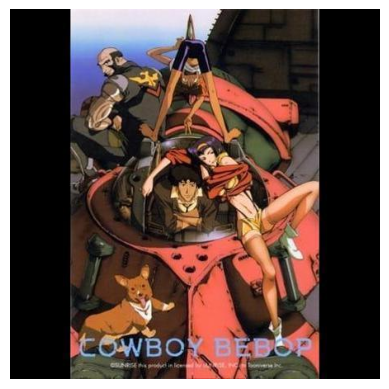

In [16]:
image_path = "../data/images/1.jpg"
img = Image.open(image_path)

plt.imshow(img)
plt.axis('off')
plt.show()

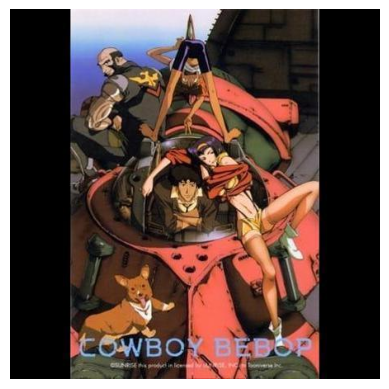

In [17]:
width, height = img.size
max_side = max(width, height)

new_img = Image.new("RGB", (max_side, max_side), (0, 0, 0))

left = (max_side - width) // 2
top = (max_side - height) // 2
new_img.paste(img, (left, top))

plt.imshow(new_img)
plt.axis('off')
plt.show()

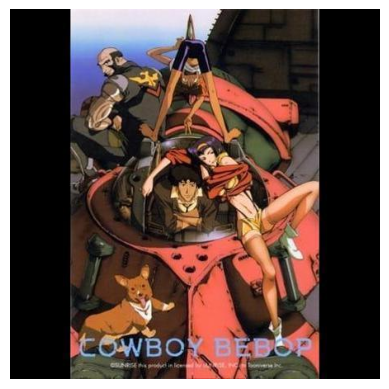

In [18]:
resized_img = new_img.resize((448, 448))

plt.imshow(resized_img)
plt.axis('off')
plt.show()

This works. Now we turn this into a pipeline:

In [19]:
def process_image(mal_id):
    image_path = "../data/images/" + str(mal_id) + ".jpg"
    target_dir = Path("../data/images")
    file_name = str(mal_id) + ".jpg"
    image_path_true = Path(image_path)
    if image_path_true.exists():
        img = Image.open(image_path)
    
        width, height = img.size
        max_side = max(width, height)
        
        new_img = Image.new("RGB", (max_side, max_side), (0, 0, 0))
        left = (max_side - width) // 2
        top = (max_side - height) // 2
        new_img.paste(img, (left, top))
    
        resized_img = new_img.resize((448, 448))
    
        resized_img.save(target_dir / file_name)

Now we iterate throughout the entire processed CSV:

In [20]:
# display_count = 0

# for mal_id in df3["mal_id"]:
#     process_image(mal_id)
#     if display_count == 1000:
#         display_count = 0
#         print(f"Processed 1000 images! Current ID: {mal_id}")
#     else:
#         display_count += 1

Now we want to translate these images into vectors that we can actually feed into our neural network. For this, we will use wd-eva02. We will start with the Cowboy Bebop test image.

In [21]:
model = timm.create_model("hf_hub:SmilingWolf/wd-eva02-large-tagger-v3", pretrained=True)
model.eval()

Eva(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (rope): RotaryEmbeddingCat()
  (norm_pre): Identity()
  (blocks): ModuleList(
    (0-23): 24 x EvaBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): EvaAttention(
        (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
        (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True, bias=True)
      (mlp): S

In [22]:
data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)
image_path = "../data/images/1.jpg"
test_img = Image.open(image_path)
test_tensor = transforms(test_img).unsqueeze(0)
with torch.no_grad():
    embedding = model(test_tensor)

print("Embedding Shape:", embedding.shape)

Embedding Shape: torch.Size([1, 10861])


In [23]:
embedding

tensor([[ -1.2063,   0.3103,  -2.5475,  ..., -12.8387, -11.9953, -11.9118]])

Looks good. Let's get all the images from our current mal_id's. If the mal_id doesn't exist in the image folder, we will put a black image by default.

In [36]:
image_embeddings = []
count = 0

for mal_id in df4['mal_id']:
    # print(mal_id)
    image_path = "../data/images/" + str(mal_id) + ".jpg"
    target_dir = Path("../data/images")
    file_name = str(mal_id) + ".jpg"
    image_path_true = Path(image_path)

    if image_path_true.exists():
        # print("Path found!")
        img = Image.open(image_path)
    else:
        img = Image.new("RGB", (448, 448), (0, 0, 0))

    img_tensor = transforms(img).unsqueeze(0)

    with torch.no_grad():
        embedding = model(img_tensor)
        # print(embedding)

    image_embeddings.append(embedding)

    count += 1

    if count % 10 == 0:
            print(f"{count} images finished! Current MAL ID: {mal_id}")

image_embeddings = torch.cat(image_embeddings, dim=0)

print("Embedding Shape:", image_embeddings.shape)

10 images finished! Current MAL ID: 20
20 images finished! Current MAL ID: 33
30 images finished! Current MAL ID: 59
40 images finished! Current MAL ID: 69
50 images finished! Current MAL ID: 85
60 images finished! Current MAL ID: 98
70 images finished! Current MAL ID: 109
80 images finished! Current MAL ID: 121
90 images finished! Current MAL ID: 133
100 images finished! Current MAL ID: 147
110 images finished! Current MAL ID: 159
120 images finished! Current MAL ID: 170
130 images finished! Current MAL ID: 183
140 images finished! Current MAL ID: 200
150 images finished! Current MAL ID: 225
160 images finished! Current MAL ID: 237
170 images finished! Current MAL ID: 247
180 images finished! Current MAL ID: 263
190 images finished! Current MAL ID: 276
200 images finished! Current MAL ID: 287
210 images finished! Current MAL ID: 297
220 images finished! Current MAL ID: 311
230 images finished! Current MAL ID: 329
240 images finished! Current MAL ID: 339
250 images finished! Current MA

In [37]:
image_embeddings

tensor([[ -1.2063,   0.3103,  -2.5475,  ..., -12.8387, -11.9953, -11.9118],
        [  1.5139,  -1.0033,  -5.9383,  ..., -10.6041, -11.7155, -11.3837],
        [ -0.7981,   1.2909,  -7.3417,  ..., -13.6375, -13.1361, -12.3068],
        ...,
        [  2.6908,  -2.1458,  -6.3109,  ..., -11.3831, -12.4180, -12.7417],
        [  4.3301,  -3.7321,  -5.9692,  ..., -13.5991,  -8.4785,  -7.6218],
        [ -0.6665,   1.5292,  -6.0202,  ...,  -8.7078, -13.1317, -13.4396]])

Now we involve PCA.

In [38]:
pca_full = PCA().fit(image_embeddings)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
# find smallest n where cumvar[n] >= 0.90, e.g.
n_90 = np.argmax(cumvar >= 0.90) + 1
n_90

np.int64(417)

In [40]:
pca = PCA(n_components=417)
compressed = pca.fit_transform(image_embeddings)
compressed

array([[ 16.04060009,  27.01164224,  13.18493951, ...,   2.35740067,
          1.03187191,  -6.09961691],
       [-56.91146765,  35.71243164,  33.96431123, ...,  -1.33213459,
          1.08393977,  -5.28729959],
       [-57.55532332,  13.14860688,  35.454243  , ...,   2.3543235 ,
          0.17365551,   2.72752439],
       ...,
       [-45.77613824,  -2.20948031,  40.40448539, ...,  -0.20397755,
          3.45123714,  -2.44797956],
       [ 10.93952569, -44.55263569, -23.44916759, ...,  -1.45285696,
          3.64598101,  -3.66973268],
       [ 85.02304483,   0.79799322, -17.82544951, ...,  -0.22471454,
          6.53767078,  10.19574293]], shape=(5338, 417))

In [41]:
target_dir = Path("../data/processed")
file_path = target_dir / "image_embeddings.npy"
np.save(file_path, image_embeddings)

## Synopsis

We want to store synopses as a bunch of vectors via all-mpnet-base-v2.

In [21]:
# sentences = ["This is an example sentence", "Each sentence is converted"]

# model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
# embeddings = model.encode(sentences)
# print(embeddings)

In [22]:
# embeddings = model.encode(
#     df3['synopsis'].tolist(),
#     batch_size=32,          # Adjust based on your VRAM
#     show_progress_bar=True,
#     convert_to_numpy=True
# )
# print(embeddings)

In [23]:
# target_dir = Path("../data/processed")
# file_path = target_dir / "semantic_embeddings.npy"
# np.save(file_path, embeddings)

Raw embeddings saved as backup. We will use PCA to try to compress this (we may or may not use this later on).

In [24]:
# pca_full = PCA().fit(embeddings)
# cumvar = np.cumsum(pca_full.explained_variance_ratio_)
# # find smallest n where cumvar[n] >= 0.90, e.g.
# n_90 = np.argmax(cumvar >= 0.90) + 1
# n_90

In [25]:
# pca = PCA(n_components=193)
# compressed = pca.fit_transform(embeddings)
# compressed

In [26]:
# target_dir = Path("../data/processed")
# file_path = target_dir / "compressed_embeddings.npy"
# np.save(file_path, compressed)

## Multi-valued Features

Five features can have multiple values: producers, genres, studios, demographics, and themes.

In [27]:
df4['genres']

0              [Action, Award Winning, Sci-Fi]
1                  [Action, Adventure, Sci-Fi]
2       [Action, Drama, Mystery, Supernatural]
3                 [Action, Adventure, Fantasy]
4                                     [Sports]
                         ...                  
8719               [Fantasy, Gourmet, Romance]
8726                                 [Romance]
8735              [Action, Adventure, Fantasy]
8741                         [Comedy, Romance]
8816                    [Comedy, Supernatural]
Name: genres, Length: 5338, dtype: object

First, do some diagnostics for themes and genres. What we want to decide on is "which genres and themes should be bucketed into an 'other' section?"

In [28]:
theme_counts = df4['themes'].explode().value_counts()
genre_counts = df4['genres'].explode().value_counts()

print(theme_counts)
print(f"\nTotal unique themes: {len(theme_counts)}")
print(f"Themes appearing <50 times: {(theme_counts < 50).sum()}")

themes
School               1032
Mecha                 414
Historical            364
Adult Cast            335
Harem                 273
Isekai                269
Super Power           238
Music                 232
Military              219
Parody                204
Mythology             184
Strategy Game         168
Psychological         162
Space                 161
Anthropomorphic       153
Mahou Shoujo          147
Gag Humor             139
CGDCT                 130
Team Sports           119
Workplace             119
Urban Fantasy         118
Reincarnation         110
Martial Arts          107
Gore                  105
Idols (Female)         95
Samurai                92
Iyashikei              87
Detective              79
Vampire                76
Racing                 74
Love Polygon           72
Time Travel            66
Otaku Culture          63
Performing Arts        62
Pets                   56
Organized Crime        53
Video Game             46
Reverse Harem          44
Child

In [29]:
threshold = 50
rare_themes = theme_counts[theme_counts < threshold].index.tolist()
print(sorted(rare_themes))

['Childcare', 'Combat Sports', 'Crossdressing', 'Delinquents', 'Educational', 'High Stakes Game', 'Idols (Male)', 'Love Status Quo', 'Magical Sex Shift', 'Medical', 'Reverse Harem', 'Showbiz', 'Survival', 'Video Game', 'Villainess', 'Visual Arts']


In [30]:
def bucket_rare(theme_list, rare_set):
    return [t if t not in rare_set else "Other" for t in theme_list]

df4['themes_bucketed'] = df4['themes'].apply(lambda x: bucket_rare(x, set(rare_themes)))
df4['themes_bucketed']

0                 [Adult Cast, Space]
1                        [Adult Cast]
2                         [Detective]
3                                  []
4                       [Team Sports]
                    ...              
8719                         [Isekai]
8726    [Other, Love Polygon, School]
8735          [Isekai, Reincarnation]
8741                         [School]
8816                               []
Name: themes_bucketed, Length: 5338, dtype: object

Now for genres:

In [31]:
print(genre_counts)
print(f"\nTotal unique genres: {len(genre_counts)}")
print(f"Genres appearing <50 times: {(genre_counts < 50).sum()}")

genres
Comedy           2128
Action           1476
Fantasy          1302
Adventure        1191
Sci-Fi            980
Romance           960
Drama             919
Supernatural      518
Mystery           376
Ecchi             334
Slice of Life     305
Sports            276
Suspense          187
Horror            155
Gourmet            78
Award Winning      59
Girls Love         48
Boys Love          37
Avant Garde        35
Erotica            12
Name: count, dtype: int64

Total unique genres: 20
Genres appearing <50 times: 4


In [32]:
threshold = 50
rare_genres = genre_counts[genre_counts < threshold].index.tolist()
print(sorted(rare_genres))

['Avant Garde', 'Boys Love', 'Erotica', 'Girls Love']


In [33]:
df4['genres_bucketed'] = df4['genres'].apply(lambda x: bucket_rare(x, set(rare_genres)))
df4['genres_bucketed']

0              [Action, Award Winning, Sci-Fi]
1                  [Action, Adventure, Sci-Fi]
2       [Action, Drama, Mystery, Supernatural]
3                 [Action, Adventure, Fantasy]
4                                     [Sports]
                         ...                  
8719               [Fantasy, Gourmet, Romance]
8726                                 [Romance]
8735              [Action, Adventure, Fantasy]
8741                         [Comedy, Romance]
8816                    [Comedy, Supernatural]
Name: genres_bucketed, Length: 5338, dtype: object

Now we perform multi-label binarization:

In [34]:
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(df4['genres_bucketed'])
genre_matrix

array([[1, 0, 1, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 1, 0],
       ...,
       [1, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]], shape=(5338, 17))

In [35]:
genre_df = pd.DataFrame(
    genre_matrix,
    columns=[f"genre_{g.lower()}" for g in mlb.classes_],  # e.g. genre_Action, genre_Comedy
    index=df4.index
)

df4 = pd.concat([df4, genre_df], axis=1)
df4.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 37 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mal_id               5338 non-null   int64  
 1   title                5338 non-null   str    
 2   source               5338 non-null   str    
 3   episodes             5338 non-null   float64
 4   synopsis             5338 non-null   str    
 5   producers            5338 non-null   object 
 6   genres               5338 non-null   object 
 7   studios              5338 non-null   object 
 8   demographics         5338 non-null   object 
 9   themes               5338 non-null   object 
 10  rating               5338 non-null   str    
 11  sequel               5338 non-null   bool   
 12  cohort               5338 non-null   str    
 13  wc_z                 5338 non-null   float64
 14  forum_z              5338 non-null   float64
 15  favorites_z          5338 non-null   float64
 16  scor

In [36]:
demo_matrix = mlb.fit_transform(df4['demographics'])
demo_matrix

demo_df = pd.DataFrame(
    demo_matrix,
    columns=[f"demo_{g.lower()}" for g in mlb.classes_],  # e.g. genre_Action, genre_Comedy
    index=df4.index
)

df4 = pd.concat([df4, demo_df], axis=1)
df4.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mal_id               5338 non-null   int64  
 1   title                5338 non-null   str    
 2   source               5338 non-null   str    
 3   episodes             5338 non-null   float64
 4   synopsis             5338 non-null   str    
 5   producers            5338 non-null   object 
 6   genres               5338 non-null   object 
 7   studios              5338 non-null   object 
 8   demographics         5338 non-null   object 
 9   themes               5338 non-null   object 
 10  rating               5338 non-null   str    
 11  sequel               5338 non-null   bool   
 12  cohort               5338 non-null   str    
 13  wc_z                 5338 non-null   float64
 14  forum_z              5338 non-null   float64
 15  favorites_z          5338 non-null   float64
 16  scor

In [37]:
theme_matrix = mlb.fit_transform(df4['themes_bucketed'])
theme_matrix

theme_df = pd.DataFrame(
    theme_matrix,
    columns=[f"theme_{g.lower()}" for g in mlb.classes_],  # e.g. genre_Action, genre_Comedy
    index=df4.index
)

df4 = pd.concat([df4, theme_df], axis=1)
df4.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 79 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   mal_id                 5338 non-null   int64  
 1   title                  5338 non-null   str    
 2   source                 5338 non-null   str    
 3   episodes               5338 non-null   float64
 4   synopsis               5338 non-null   str    
 5   producers              5338 non-null   object 
 6   genres                 5338 non-null   object 
 7   studios                5338 non-null   object 
 8   demographics           5338 non-null   object 
 9   themes                 5338 non-null   object 
 10  rating                 5338 non-null   str    
 11  sequel                 5338 non-null   bool   
 12  cohort                 5338 non-null   str    
 13  wc_z                   5338 non-null   float64
 14  forum_z                5338 non-null   float64
 15  favorites_z         

Now we check producers and studios:

In [38]:
all_studios = set(df4['studios'].explode().dropna())
all_producers = set(df4['producers'].explode().dropna())

overlap = all_studios & all_producers
print(f"Studios: {len(all_studios)}, Producers: {len(all_producers)}")
print(f"Overlapping names: {len(overlap)}")
print(f"% of producer entries that are also studios: {len(overlap)/len(all_producers):.1%}")

Studios: 522, Producers: 1086
Overlapping names: 174
% of producer entries that are also studios: 16.0%


In [39]:
def kfold_target_encode(df, col, target, n_splits=5):
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df):
        means = df.iloc[train_idx].explode(col).groupby(col)[target].mean()
        # for multi-valued rows, average across entries' encoded means
        encoded.iloc[val_idx] = df.iloc[val_idx][col].apply(
            lambda lst: pd.Series(lst).map(means).mean()
        )
    return encoded

df4['studio_enc'] = kfold_target_encode(df4, 'studios', 'score_z')
df4['producer_enc'] = kfold_target_encode(df4, 'producers', 'score_z')

print(df4[['studio_enc', 'producer_enc']].corr())

              studio_enc  producer_enc
studio_enc      1.000000      0.365622
producer_enc    0.365622      1.000000


Reasonably low correlation. We can make a separate learned embedding from this.

In [40]:
df4.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 81 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   mal_id                 5338 non-null   int64  
 1   title                  5338 non-null   str    
 2   source                 5338 non-null   str    
 3   episodes               5338 non-null   float64
 4   synopsis               5338 non-null   str    
 5   producers              5338 non-null   object 
 6   genres                 5338 non-null   object 
 7   studios                5338 non-null   object 
 8   demographics           5338 non-null   object 
 9   themes                 5338 non-null   object 
 10  rating                 5338 non-null   str    
 11  sequel                 5338 non-null   bool   
 12  cohort                 5338 non-null   str    
 13  wc_z                   5338 non-null   float64
 14  forum_z                5338 non-null   float64
 15  favorites_z         

In [ ]:
# Keep original categorical features for statistical analysis
df5 = df4.drop(columns=['synopsis', 'themes_bucketed', 'genres_bucketed', 'studio_enc', 'producer_enc'])
df5.columns = df5.columns.str.replace(' ', '_')
df5.info()

<class 'pandas.DataFrame'>
Index: 5338 entries, 0 to 8816
Data columns (total 76 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   mal_id                 5338 non-null   int64  
 1   title                  5338 non-null   str    
 2   source                 5338 non-null   str    
 3   episodes               5338 non-null   float64
 4   producers              5338 non-null   object 
 5   genres                 5338 non-null   object 
 6   studios                5338 non-null   object 
 7   demographics           5338 non-null   object 
 8   themes                 5338 non-null   object 
 9   rating                 5338 non-null   str    
 10  sequel                 5338 non-null   bool   
 11  cohort                 5338 non-null   str    
 12  wc_z                   5338 non-null   float64
 13  forum_z                5338 non-null   float64
 14  favorites_z            5338 non-null   float64
 15  score_z             

## Source Material

For all accessible source material types, we have gathered the score and member count for every work. We can access and potentially normalize the distributions:

In [44]:
init_dir = Path("../data/stats")
init_score = init_dir / "scores.json"
init_members = init_dir / "members.json"

try:
    with open(init_score, "r", encoding="utf-8") as file:
        score_data = json.load(file)
except FileNotFoundError:
    print(f"Error: The file at {init_score} was not found.")
except json.JSONDecodeError:
    print("Error: The file contains invalid JSON.")

try:
    with open(init_members, "r", encoding="utf-8") as file:
        member_data  = json.load(file)
except FileNotFoundError:
    print(f"Error: The file at {init_members} was not found.")
except json.JSONDecodeError:
    print("Error: The file contains invalid JSON.") 

In [55]:
print(list(score_data.keys()))
print(list(member_data.keys()))

['Manga', 'Light Novel', 'Novel', 'Doujinshi', 'One-shot', 'Manhwa', 'Manhua']
['Manga', 'Light Novel', 'Novel', 'Doujinshi', 'One-shot', 'Manhwa', 'Manhua']


### Manga

Text(0, 0.5, 'Count')

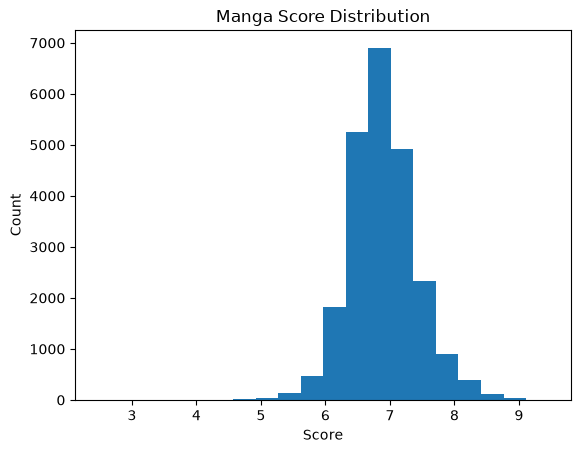

In [46]:
plt.hist(score_data['Manga'], bins=20)
plt.title("Manga Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

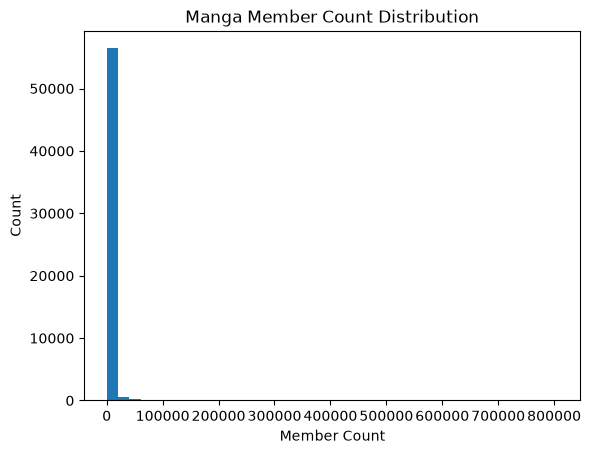

In [50]:
plt.hist(member_data['Manga'], bins=40)
plt.title("Manga Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

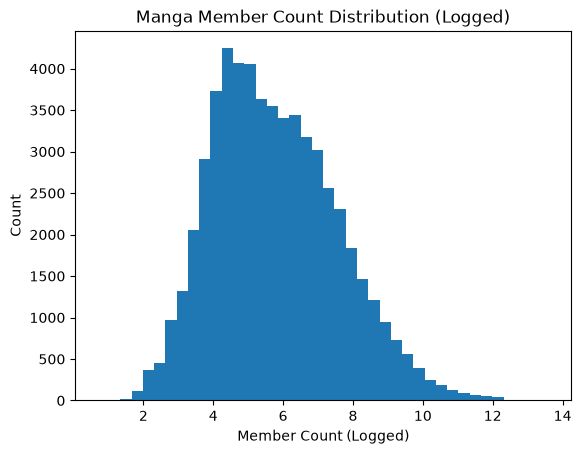

In [51]:
skewed_manga_members = np.log1p(member_data['Manga'])
plt.hist(skewed_manga_members, bins=40)
plt.title("Manga Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### Light Novel

Text(0, 0.5, 'Count')

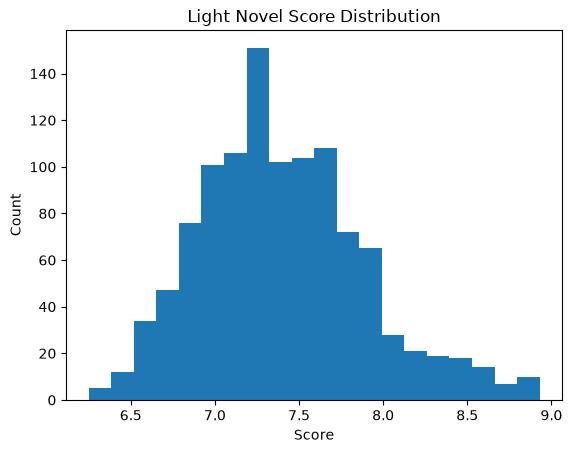

In [52]:
plt.hist(score_data['Light Novel'], bins=20)
plt.title("Light Novel Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

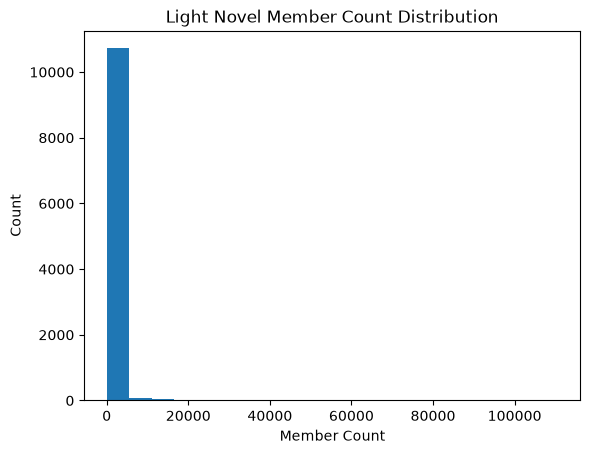

In [53]:
plt.hist(member_data['Light Novel'], bins=20)
plt.title("Light Novel Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

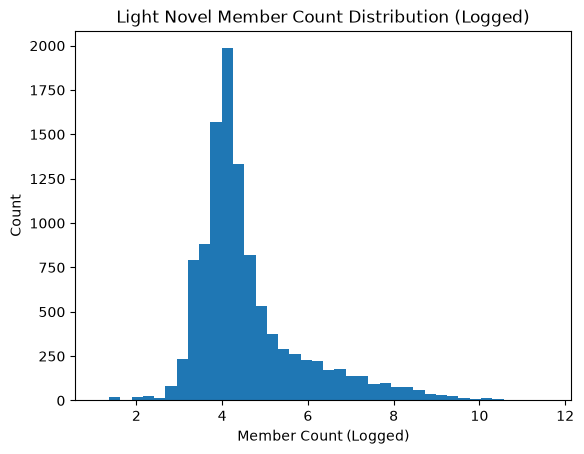

In [54]:
skewed_ln_members = np.log1p(member_data['Light Novel'])
plt.hist(skewed_ln_members, bins=40)
plt.title("Light Novel Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### Novel

Text(0, 0.5, 'Count')

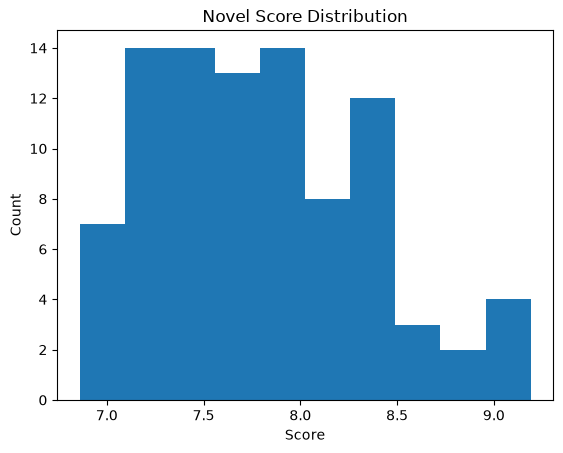

In [57]:
plt.hist(score_data['Novel'])
plt.title("Novel Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

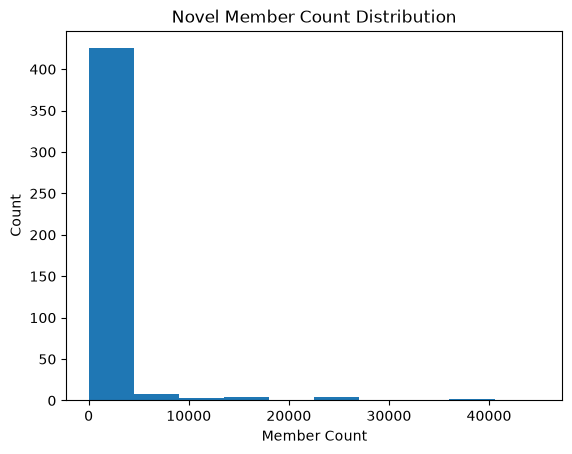

In [58]:
plt.hist(member_data['Novel'])
plt.title("Novel Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

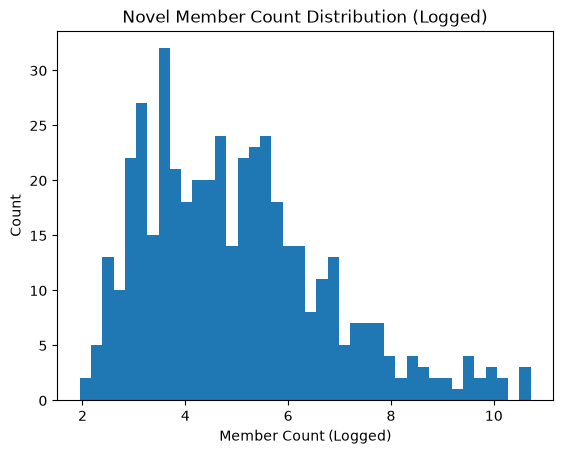

In [59]:
skewed_novel_members = np.log1p(member_data['Novel'])
plt.hist(skewed_novel_members, bins=40)
plt.title("Novel Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### Doujinshi

Text(0, 0.5, 'Count')

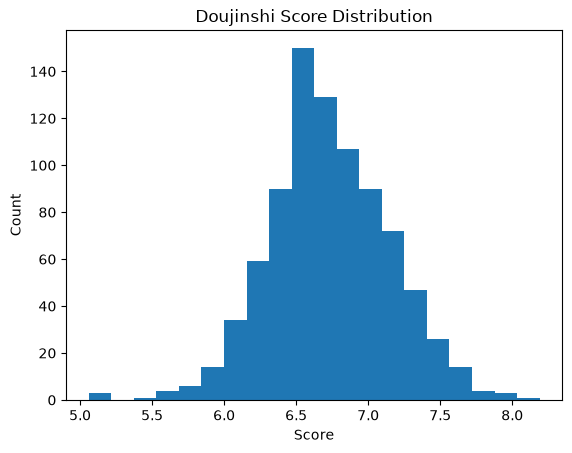

In [62]:
plt.hist(score_data['Doujinshi'], bins=20)
plt.title("Doujinshi Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

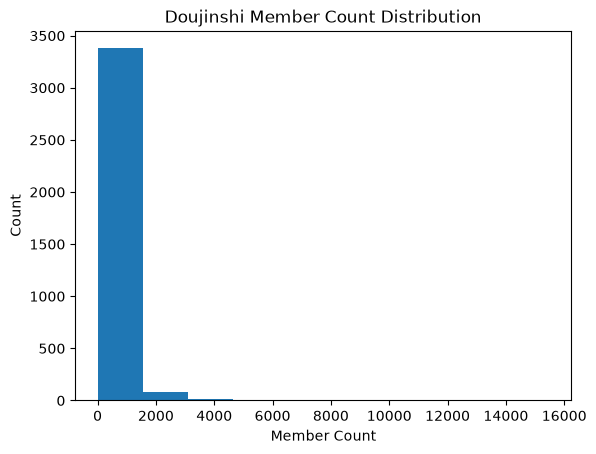

In [63]:
plt.hist(member_data['Doujinshi'])
plt.title("Doujinshi Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

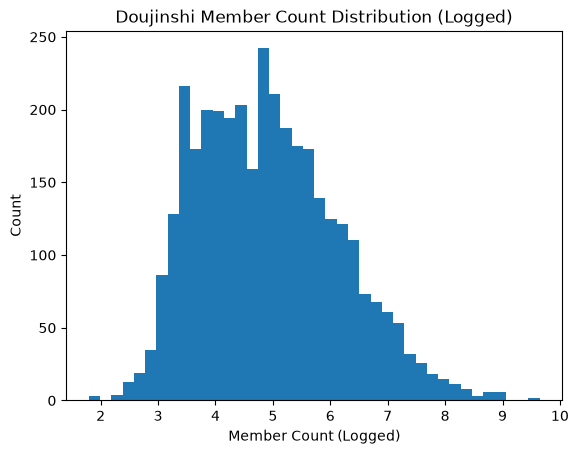

In [64]:
skewed_doujinshi_members = np.log1p(member_data['Doujinshi'])
plt.hist(skewed_doujinshi_members, bins=40)
plt.title("Doujinshi Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### One-shot

Text(0, 0.5, 'Count')

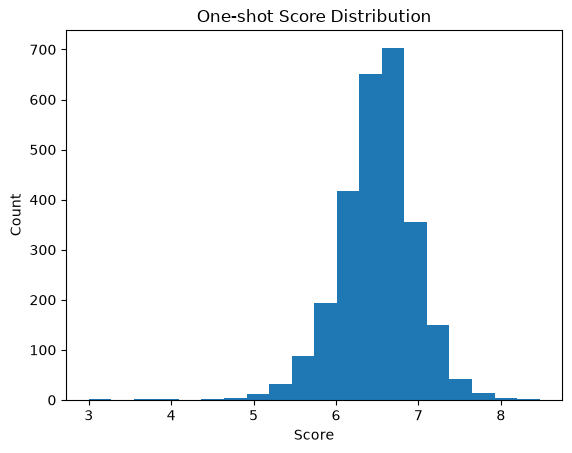

In [65]:
plt.hist(score_data['One-shot'], bins=20)
plt.title("One-shot Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

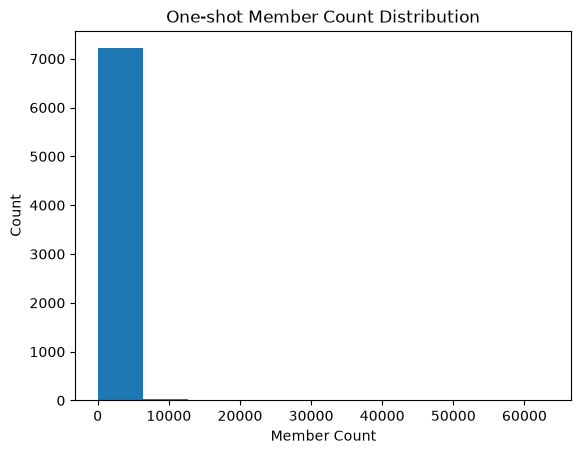

In [66]:
plt.hist(member_data['One-shot'])
plt.title("One-shot Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

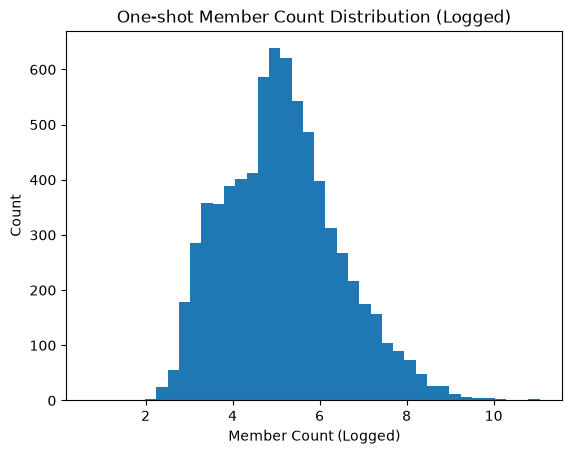

In [67]:
skewed_oneshot_members = np.log1p(member_data['One-shot'])
plt.hist(skewed_oneshot_members, bins=40)
plt.title("One-shot Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### Manhwa

Text(0, 0.5, 'Count')

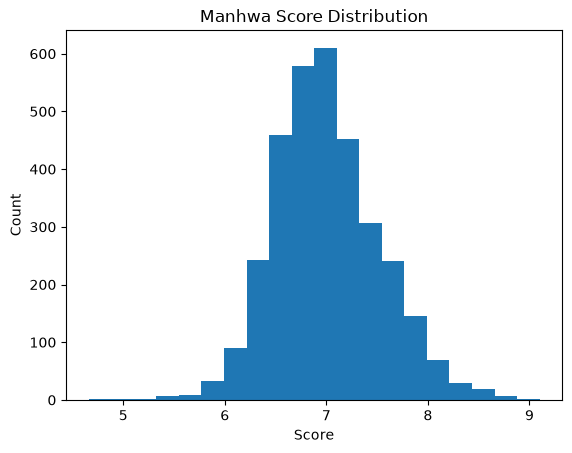

In [68]:
plt.hist(score_data['Manhwa'], bins=20)
plt.title("Manhwa Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

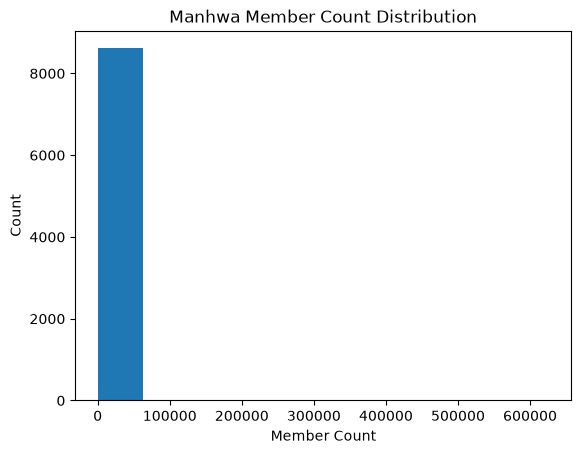

In [69]:
plt.hist(member_data['Manhwa'])
plt.title("Manhwa Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

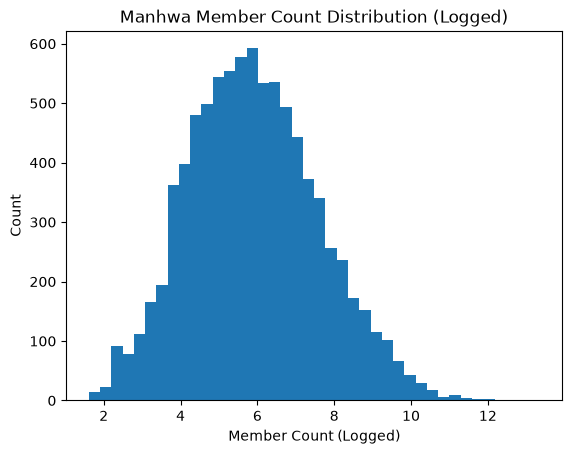

In [73]:
skewed_manhwa_members = np.log1p(member_data['Manhwa'])
plt.hist(skewed_manhwa_members, bins=40)
plt.title("Manhwa Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

### Manhua

Text(0, 0.5, 'Count')

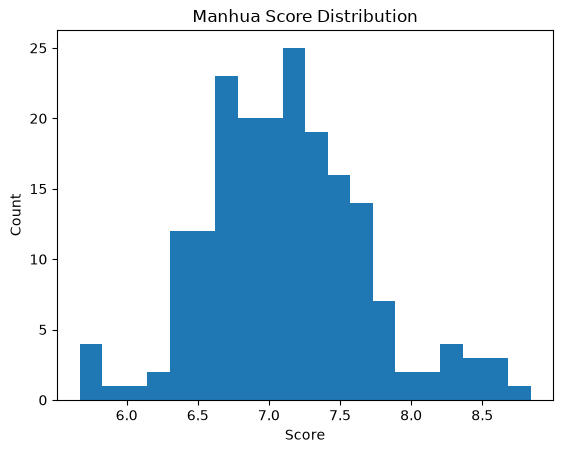

In [71]:
plt.hist(score_data['Manhua'], bins=20)
plt.title("Manhua Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

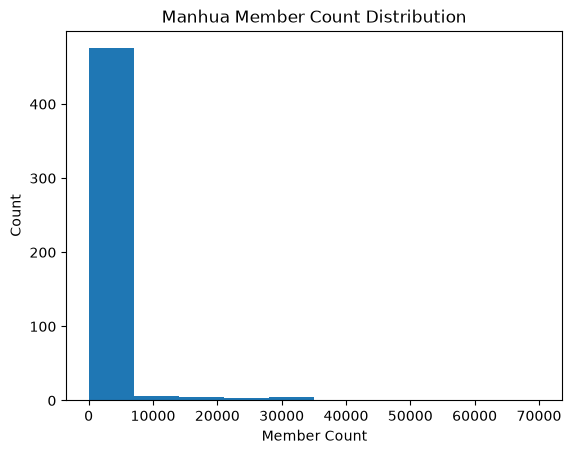

In [72]:
plt.hist(member_data['Manhua'])
plt.title("Manhua Member Count Distribution")
plt.xlabel("Member Count")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

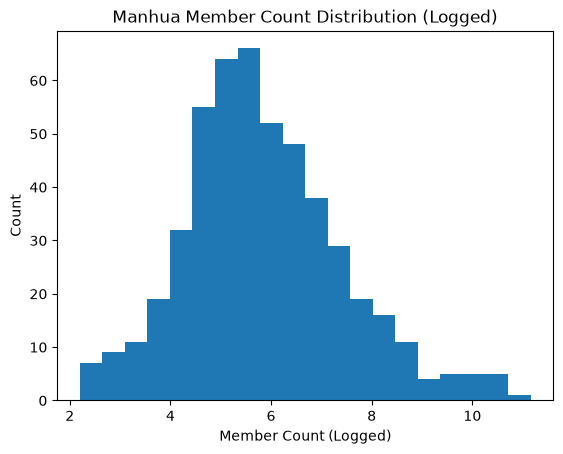

In [75]:
skewed_manhua_members = np.log1p(member_data['Manhua'])
plt.hist(skewed_manhua_members, bins=20)
plt.title("Manhua Member Count Distribution (Logged)")
plt.xlabel("Member Count (Logged)")
plt.ylabel("Count")

In [60]:
target_dir = Path("../data/processed")
file_path = target_dir / "anime_data_2.parquet"

df5.to_parquet(file_path, engine="pyarrow")

NameError: name 'df5' is not defined